In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
from pathlib import Path

input_path = Path(
    "../MachineLearning2026/data/processed/olist_orders_feature_engineered.csv"
)

df = pd.read_csv(input_path)

print("Shape:", df.shape)
df.head()

Shape: (99441, 23)


,total_price,total_freight,total_items,unique_products,unique_sellers,order_month,order_day_of_week,order_hour,average_item_price,freight_ratio,...,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,29.99,8.72,1.0,1.0,1.0,10,0,10,29.99,0.290764,...,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99,0
1,118.70,22.76,1.0,1.0,1.0,7,1,20,118.70,0.191744,...,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70,0
2,159.90,19.22,1.0,1.0,1.0,8,2,8,159.90,0.120200,...,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90,0
3,45.00,27.20,1.0,1.0,1.0,11,5,19,45.00,0.604444,...,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00,0
4,19.90,8.72,1.0,1.0,1.0,2,1,21,19.90,0.438191,...,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90,0


In [5]:
target = "is_late_delivery"

print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True))

is_late_delivery
0    92906
1     6535
Name: count, dtype: int64

is_late_delivery
0    0.934283
1    0.065717
Name: proportion, dtype: float64


In [6]:
y = df[target]

X = df.drop(columns=[target])

X = X.select_dtypes(include=np.number)

X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99441, 22)
y shape: (99441,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (79552, 22)
Test data: (19889, 22)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:20])

[1 1 1 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0]


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10463  8119]
 [  374   933]]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.572980039217658
Precision: 0.10307114449845338
Recall   : 0.7138485080336648
F1 Score : 0.18013321749203592


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.56      0.71     18582
           1       0.10      0.71      0.18      1307

    accuracy                           0.57     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.57      0.68     19889



In [20]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6661469372051521


In [21]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:10])

[0.58334345 0.61016614 0.57087306 0.43899673 0.58411974 0.61453863
 0.35726569 0.3189453  0.36581789 0.56816637]


In [22]:
from sklearn.metrics import recall_score

threshold = 0.40

y_pred_40 = (y_prob >= threshold).astype(int)

recall_40 = recall_score(
    y_test,
    y_pred_40,
    zero_division=0
)

print("Recall at threshold 0.40:", recall_40)

Recall at threshold 0.40: 0.8355011476664116


In [23]:
from sklearn.metrics import precision_score, recall_score

y_pred_50 = (y_prob >= 0.50).astype(int)
y_pred_40 = (y_prob >= 0.40).astype(int)

print("Threshold 0.50")
print("Precision:", precision_score(y_test, y_pred_50, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_50, zero_division=0))

print()

print("Threshold 0.40")
print("Precision:", precision_score(y_test, y_pred_40, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_40, zero_division=0))

Threshold 0.50
Precision: 0.10307114449845338
Recall   : 0.7138485080336648

Threshold 0.40
Precision: 0.08471026297416802
Recall   : 0.8355011476664116


In [24]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation created!")

5-fold cross-validation created!


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

Scores: [0.17404836 0.17505418 0.17765457 0.17650654 0.17810716]
Mean: 0.17627416142585312
Std: 0.0015337508875805886


In [27]:
from sklearn.metrics import f1_score

test_f1 = f1_score(y_test, y_pred, zero_division=0)
cv_mean = cv_scores.mean()

print("Test F1-score :", test_f1)
print("CV Mean F1    :", cv_mean)
print("Difference    :", abs(test_f1 - cv_mean))

Test F1-score : 0.18013321749203592
CV Mean F1    : 0.17627416142585312
Difference    : 0.003859056066182809


In [28]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Mean Accuracy :", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall   :", cv_results["test_recall"].mean())
print("Mean F1       :", cv_results["test_f1"].mean())

Mean Accuracy : 0.57163877193855
Mean Precision: 0.10088802471534782
Mean Recall   : 0.6973988857072283
Mean F1       : 0.17627416142585312


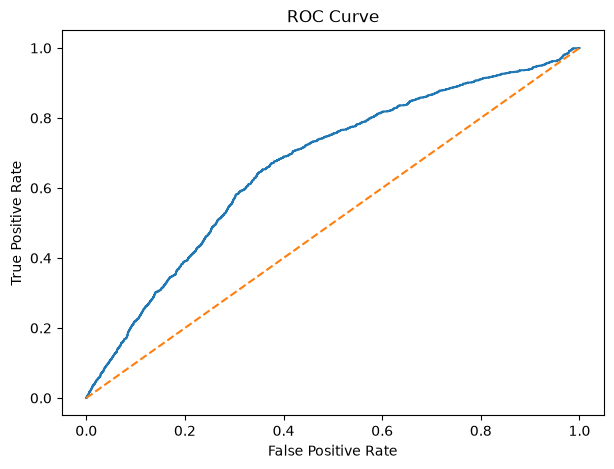

In [29]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

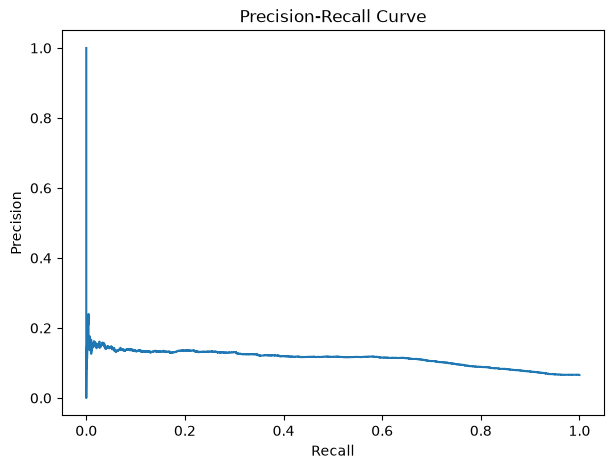

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, zero_division=0)
final_recall = recall_score(y_test, y_pred, zero_division=0)
final_f1 = f1_score(y_test, y_pred, zero_division=0)
final_auc = roc_auc_score(y_test, y_prob)

print("Final Test Results")
print("------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_auc)

Final Test Results
------------------
Accuracy : 0.572980039217658
Precision: 0.10307114449845338
Recall   : 0.7138485080336648
F1 Score : 0.18013321749203592
ROC-AUC  : 0.6661469372051521


In [32]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Test Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

results

,Metric,Test Score
0,Accuracy,0.572980
1,Precision,0.103071
2,Recall,0.713849
3,F1 Score,0.180133
4,ROC-AUC,0.666147


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.50, 0.70]

threshold_results = []

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test, predictions, zero_division=0
    )

    recall = recall_score(
        y_test, predictions, zero_division=0
    )

    f1 = f1_score(
        y_test, predictions, zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.068241,0.941852,0.127261
1,0.5,0.103071,0.713849,0.180133
2,0.7,0.146067,0.049732,0.074201


In [34]:
baseline_df = pd.read_csv(
    "../MachineLearning2026/data/processed/olist_orders_abt.csv"
)

print("Baseline shape:", baseline_df.shape)

Baseline shape: (99441, 29)


In [35]:
identifier_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

leakage_columns = [
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "review_comment_count",
    "has_review_comment",
    "is_low_review"
]

baseline_features = baseline_df.drop(
    columns=identifier_columns + leakage_columns
)

baseline_X = baseline_features.select_dtypes(
    include=np.number
).drop(
    columns=["is_late_delivery"],
    errors="ignore"
)

baseline_y = baseline_features["is_late_delivery"]

baseline_X = baseline_X.fillna(
    baseline_X.median()
)

print("Baseline X:", baseline_X.shape)
print("Baseline y:", baseline_y.shape)

Baseline X: (99441, 14)
Baseline y: (99441,)


In [36]:
baseline_X_train, baseline_X_test, baseline_y_train, baseline_y_test = train_test_split(
    baseline_X,
    baseline_y,
    test_size=0.20,
    random_state=42,
    stratify=baseline_y
)

print("Baseline training:", baseline_X_train.shape)
print("Baseline testing:", baseline_X_test.shape)

Baseline training: (79552, 14)
Baseline testing: (19889, 14)


In [38]:
baseline_scaler = StandardScaler()

baseline_X_train_scaled = baseline_scaler.fit_transform(
    baseline_X_train
)

baseline_X_test_scaled = baseline_scaler.transform(
    baseline_X_test
)

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

baseline_model.fit(
    baseline_X_train_scaled,
    baseline_y_train
)

baseline_pred = baseline_model.predict(
    baseline_X_test_scaled
)

baseline_prob = baseline_model.predict_proba(
    baseline_X_test_scaled
)[:, 1]

print("Baseline model trained!")

Baseline model trained!


In [39]:
baseline_accuracy = accuracy_score(
    baseline_y_test,
    baseline_pred
)

baseline_precision = precision_score(
    baseline_y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    baseline_y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    baseline_y_test,
    baseline_pred,
    zero_division=0
)

baseline_auc = roc_auc_score(
    baseline_y_test,
    baseline_prob
)

print("Baseline Accuracy :", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall   :", baseline_recall)
print("Baseline F1       :", baseline_f1)
print("Baseline ROC-AUC  :", baseline_auc)

Baseline Accuracy : 0.5643823218864699
Baseline Precision: 0.08663894819642656
Baseline Recall   : 0.5899005355776588
Baseline F1       : 0.15108759553204
Baseline ROC-AUC  : 0.5968695425318428


In [40]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_auc
    ],
    "Engineered": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

comparison

,Metric,Baseline,Engineered
0,Accuracy,0.564382,0.572980
1,Precision,0.086639,0.103071
2,Recall,0.589901,0.713849
3,F1 Score,0.151088,0.180133
4,ROC-AUC,0.596870,0.666147


In [41]:
pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

print("Final pipeline created!")

Final pipeline created!


In [42]:
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("CV F1 Scores:", cv_scores)
print("Mean CV F1 :", cv_scores.mean())
print("Std CV F1  :", cv_scores.std())

CV F1 Scores: [0.17404836 0.17505418 0.17765457 0.17650654 0.17810716]
Mean CV F1 : 0.17627416142585312
Std CV F1  : 0.0015337508875805886


In [43]:
pipeline.fit(
    X_train,
    y_train
)

print("Final model trained!")

Final model trained!


In [44]:
final_pred = pipeline.predict(
    X_test
)

print(final_pred[:20])

[1 1 1 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0]


In [45]:
print(
    classification_report(
        y_test,
        final_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.97      0.56      0.71     18582
           1       0.10      0.71      0.18      1307

    accuracy                           0.57     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.57      0.68     19889



In [46]:
final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    zero_division=0
)

final_prob = pipeline.predict_proba(
    X_test
)[:, 1]

final_auc = roc_auc_score(
    y_test,
    final_prob
)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "CV Mean F1",
        "CV Std F1"
    ],
    "Result": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc,
        cv_scores.mean(),
        cv_scores.std()
    ]
})

final_results

,Metric,Result
0,Accuracy,0.572980
1,Precision,0.103071
2,Recall,0.713849
3,F1-score,0.180133
4,ROC-AUC,0.666147
5,CV Mean F1,0.176274
6,CV Std F1,0.001534


In [47]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

print(final_cm)

TN, FP, FN, TP = final_cm.ravel()

print("False Negatives:", FN)

[[10463  8119]
 [  374   933]]
False Negatives: 374
